# Validating the HUXt output

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from storm_utils.config_paths import get_project_paths
import storm_utils.huxt_utils as HU

paths = get_project_paths()

HUXt and HUXt_tools paths configured.


HUXt Utilities - Example Usage


HUXt Run 3 Information
Location: /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt3
Rotations: 413 (CR 1892 to 2304)
Time range: 1995-01-27 12:00:00 to 2025-11-29 22:00:00
Time resolution: 0 days 00:30:00
Time steps: 1307
First df (start, end): (1995-01-27 12:00:00, 1995-02-23 17:00:00)
Ensemble members: 2000
Total storage: 9.93 GB


HUXt Run 3 Validation
Location: /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt3
Rotations: 413 (CR 1892 to 2304)
Ensemble members: 2000

✓ No gaps in rotation sequence

✓ All sampled files passed validation

✓ HUXt run is valid and complete!

HUXt Run 3 - Validation
Location: /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt3
Total Rotations: 413
CR Range: 1892 to 2304
Ensemble Members: 2000

Sample Rotation: CR 2098
  Shape: (1307, 2000) (timesteps, ensembles)
  Time range: 2010-06-16 04:00:00 to 2010-07-13 09:00:00
  Duration: 27 days

Velocity Statistics (all ensembles):
  Mean: 

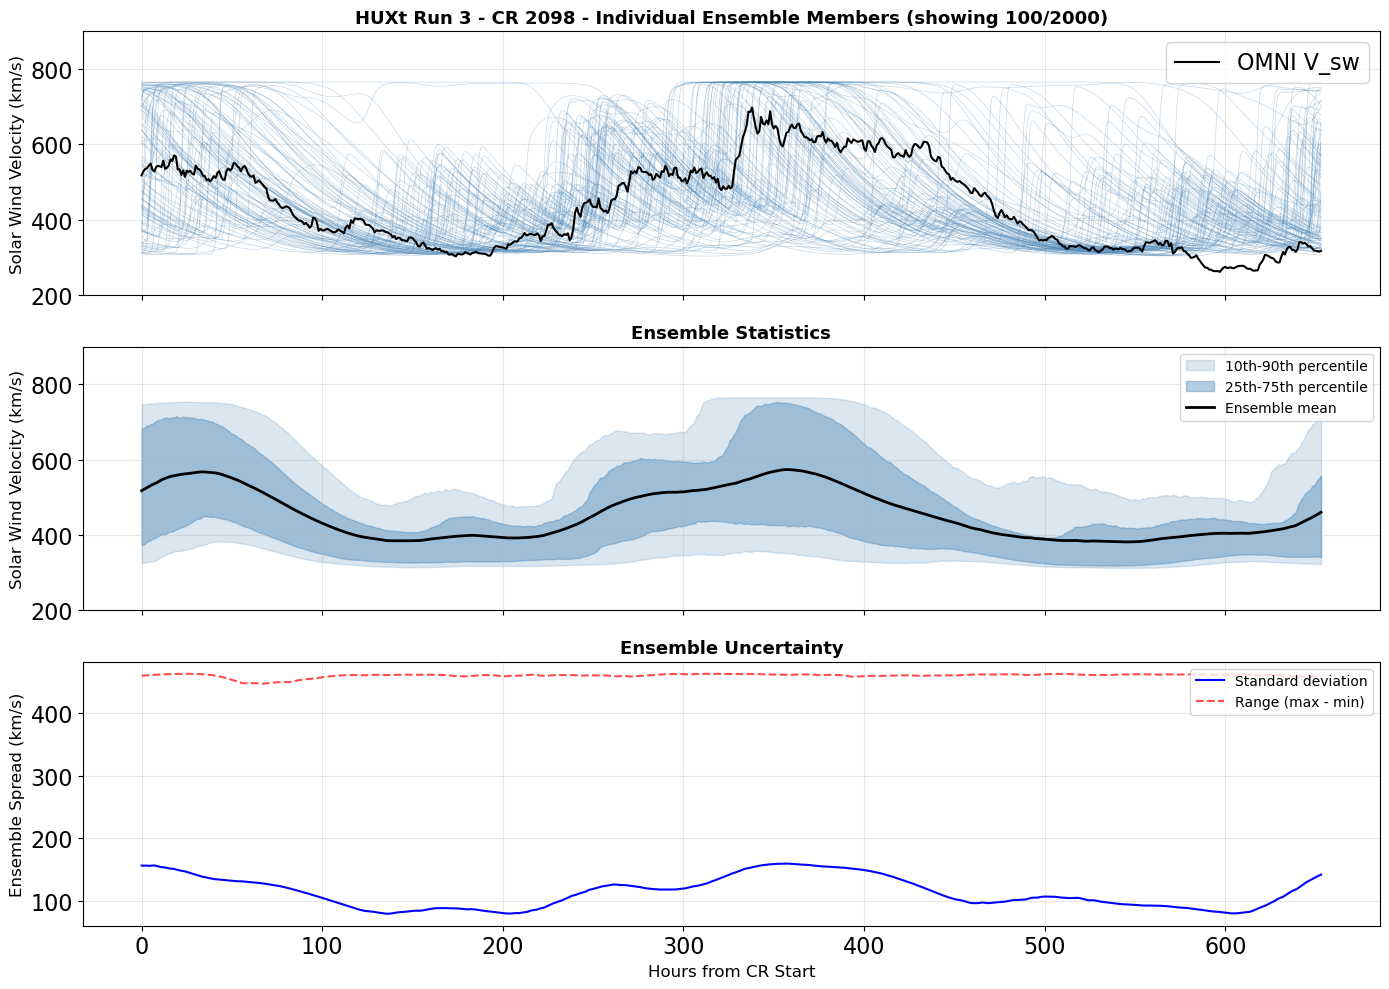


Visual Inspection Checklist:
✓ Check Panel 1: Do ensemble members look reasonable?
  - Should see variation between members
  - Typical solar wind: 300-600 km/s
  - Fast streams can reach 700-800 km/s

✓ Check Panel 2: Does ensemble mean make sense?
  - Should show temporal variability
  - Shaded regions show spread

✓ Check Panel 3: Is ensemble spread reasonable?
  - Typical std: 20-50 km/s
  - High spread = high uncertainty
  Current mean std: 113.4 km/s
  Current mean range: 459.7 km/s

Loading 5 rotations...


Loading rotations: 100%|███████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 18.48it/s]


Total timespan: 1995-01-27 12:00:00 to 1995-06-12 21:00:00
Shape: (6535, 2000)


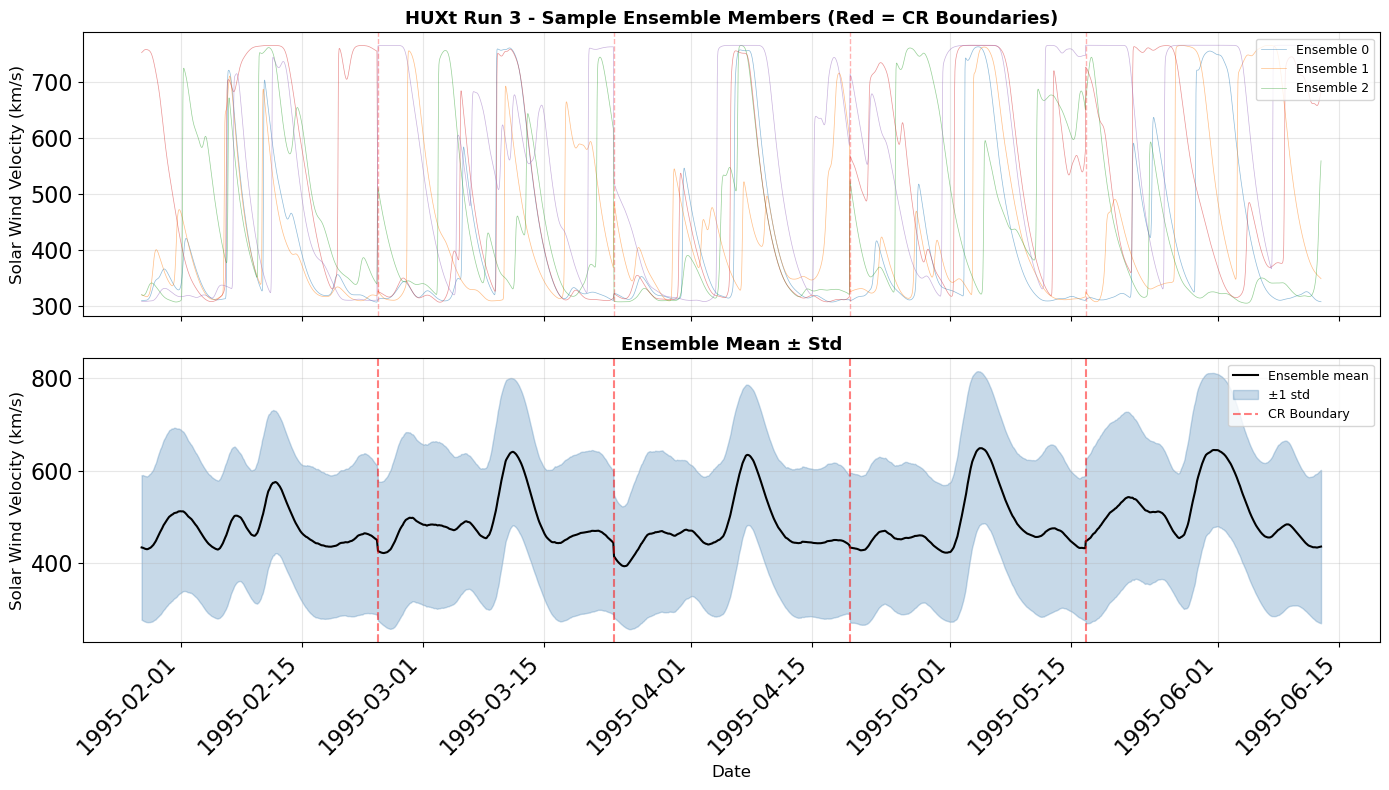


Discontinuities detected at CR boundaries:
  CR 1892 → 1893: Δv =   24.0 km/s ⚠️  MODERATE
  CR 1893 → 1894: Δv =   29.4 km/s ⚠️  MODERATE
  CR 1894 → 1895: Δv =    5.5 km/s ✓ SMALL
  CR 1895 → 1896: Δv =   14.9 km/s ✓ SMALL

Detecting discontinuities for HUXt run 3...
Checking 412 CR boundaries



Checking boundaries: 100%|█████████████████████████████████████████████████████| 412/412 [00:42<00:00,  9.72it/s]
INFO:storm_utils.huxt_utils:Saved 412 discontinuities to /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt3/discontinuities.npy



Discontinuity Detection Results
Total CR boundaries: 412
Large discontinuities (>50 km/s): 148

Large discontinuities:
  1996-06-01 11:00:00: CR 1909→1910, Δv = 84.0 km/s
  1996-09-18 09:00:00: CR 1913→1914, Δv = 111.1 km/s
  1997-06-18 07:00:00: CR 1923→1924, Δv = 80.8 km/s
  1997-09-07 23:00:00: CR 1926→1927, Δv = 85.5 km/s
  1997-11-01 12:00:00: CR 1928→1929, Δv = 61.7 km/s
  1997-12-26 03:00:00: CR 1930→1931, Δv = 62.1 km/s
  1998-01-22 12:00:00: CR 1931→1932, Δv = 62.5 km/s
  1998-02-18 20:00:00: CR 1932→1933, Δv = 87.9 km/s
  1998-08-28 13:00:00: CR 1939→1940, Δv = 89.2 km/s
  1998-10-22 02:00:00: CR 1941→1942, Δv = 64.3 km/s
  ... and 138 more



In [4]:
print("HUXt Utilities - Example Usage\n")
huxt_run_id = 3
# Get run info
info = HU.get_huxt_run_info(huxt_run_id=huxt_run_id)

# Validate
validation = HU.validate_huxt_run(huxt_run_id=huxt_run_id, expected_n_ensemble=2000)

if validation['valid']:
    print("✓ HUXt run is valid and complete!")
else:
    print("✗ Issues found - see details above")

# Plot single rotation
HU.plot_huxt_ensemble(huxt_run_id=huxt_run_id, n_members_to_plot=100)

# Plot multiple rotations
HU.plot_full_huxt_timeseries(huxt_run_id=huxt_run_id, max_rotations=5)

# Detect and save discontinuities
discontinuities = HU.detect_all_discontinuities(huxt_run_id=huxt_run_id, threshold=50, save=True)

# Combine and validate processed HUXt

In [33]:
from storm_utils.data_processing import process_huxt

# Confirm before running
response = input("\nProceed with HUXt processing? (yes/no): ")
if response.lower() != 'yes':
    print("Run cancelled")
else:
    results = process_huxt(
            huxt_run_id=3,
            chunk_size=20,
            save_discontinuities=True,
            delete_intermediates=False,
            spinup_days=1,
    )


Proceed with HUXt processing? (yes/no):  yes


INFO:storm_utils.data_processing:
INFO:storm_utils.data_processing:Processing HUXt1 to ML-Ready Format
INFO:storm_utils.data_processing:============================================================
INFO:storm_utils.data_processing:Rotations: 400
INFO:storm_utils.data_processing:Ensembles: 2000
INFO:storm_utils.data_processing:Spin-up removal: 1 days per rotation
INFO:storm_utils.data_processing:Chunk size: 20 rotations
INFO:storm_utils.data_processing:Output: /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt1_modified
INFO:storm_utils.data_processing:============================================================

INFO:storm_utils.data_processing:STEP 1: Processing individual rotations...
Processing rotations: 100%|██████████████████████████████████████████████████| 400/400 [07:08<00:00,  1.07s/it]
INFO:storm_utils.data_processing:
STEP 2: Merging into single file...
INFO:storm_utils.data_processing:Removed existing full_df.parquet
Merging chunks: 100%|████████████████████████

## Validate compatibility with ForecastingDataset

In [11]:
from storm_utils.data_structure import ForecastingDataset
from storm_utils.config_paths import get_project_paths

paths = get_project_paths()
huxt_id = 3

# Create dataset with the processed file
dataset = ForecastingDataset(
    parquet_path=str(paths['huxt_data_shared'] / f'HUXt{huxt_id}_modified' / 'full_df.parquet'),
    discontinuity_path=str(paths['huxt_data_shared'] / f'HUXt{huxt_id}_modified' / 'discontinuities.npy'),
    seed=42,
    Nens=100,
    lead_time_hours=12,
    forecast_duration_hours=24,
    stride_hours=24
)

INFO:storm_utils.data_structure:Initializing ForecastingDataset with 100 ensembles, 12h lead time, 24h forecast duration
INFO:storm_utils.data_structure:Loading data from /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt3_modified/full_df.parquet
INFO:storm_utils.data_structure:Loaded 497802 time steps
INFO:storm_utils.data_structure:Loading discontinuities from /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt3_modified/discontinuities.npy
INFO:storm_utils.data_structure:Loaded 400 discontinuities
INFO:storm_utils.data_structure:Min center index: 1272 (ensures 27-day recurrence >= 0)
INFO:storm_utils.data_structure:Filtering 10343 candidate windows against 400 discontinuities
INFO:storm_utils.data_structure:Kept 9150 valid windows after discontinuity filtering
INFO:storm_utils.data_structure:Computing maximum targets for all windows
INFO:storm_utils.data_structure:Labeling 9150 windows...
INFO:storm_utils.data_structure:
Window Classification Summary:
INFO:st

In [12]:
dataset.describe()


ForecastingDataset Summary

Dataset Configuration:
  Ensemble members (Nens): 100
  Lead time: 12 hours
  Forecast duration: 24 hours
  Stride: 24 hours
  Random seed: 42

Temporal Coverage:
  Total dataframe length: 497,802 timesteps
  Dataframe time range: 1995-01-28 12:00:00 to 2024-12-10 09:00:00
  Duration: 10908 days

Window Statistics:
  Total possible windows: 10,367
  Valid windows: 9,150
  Rejected (discontinuities): 1,217 (11.7%)
  Discontinuities: 400
  Valid window time range: 1995-02-26 02:30:00 to 2024-12-08 00:30:00
  Valid window duration: 10877 days

Storm Statistics (threshold = 4.5):
  Storms: 2,510 (27.4%)
  Non-storms: 6,640
  Mean storm strength: 5.53
  Max storm strength: 12.00

Target (Hp30 Max) Distribution:
  Min: 0.33
  25th percentile: 2.67
  Median: 3.67
  75th percentile: 4.67
  95th percentile: 6.33
  Max: 12.00
  Mean: 3.72
  Std: 1.42

Solar Wind Event Classification:
  quiet: 5667 (61.9%)
  SIR_input: 1384 (15.1%)
  ICME_input: 1013 (11.1%)
  SIR_for

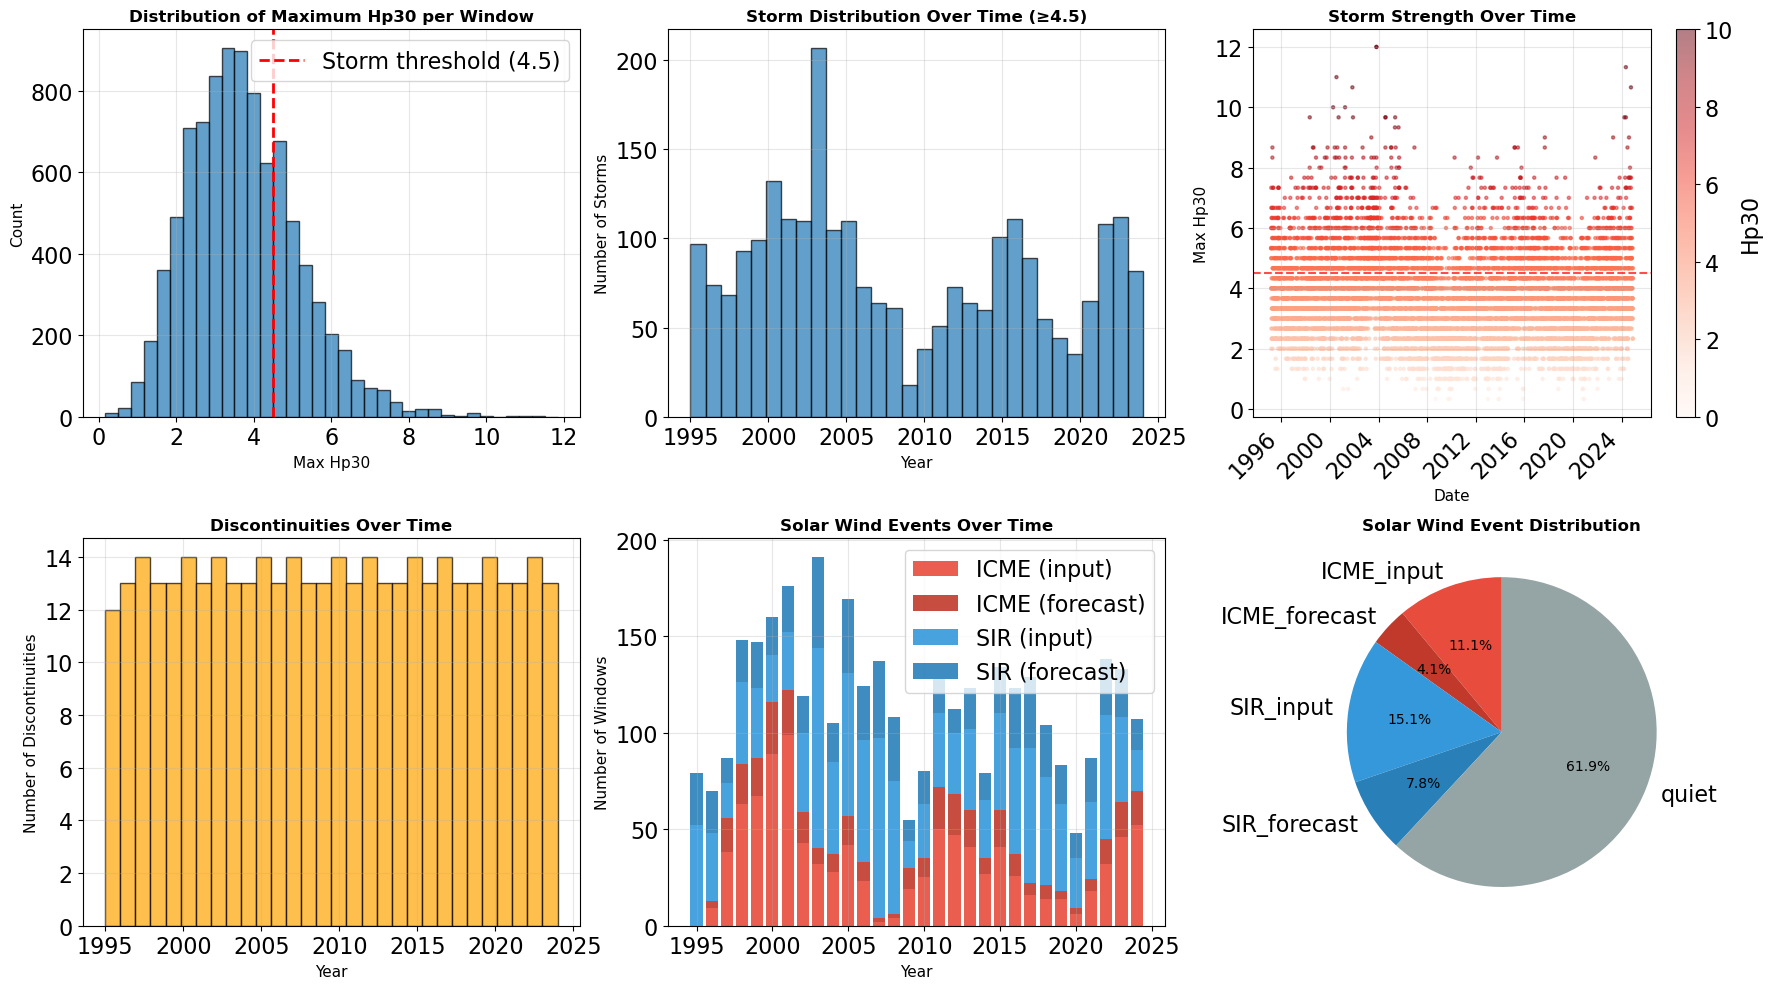

In [14]:
## Available functions for checking ForecastingDataset are: 
# ForecastingDataset.describe()
# ForecastingDataset.plot_dataset_overview()
# ForecastingDataset.plot_reduced_dataset_overview()
# ForecastingDataset.get_storm_statistics()

dataset.plot_dataset_overview()

INFO:storm_utils.data_structure:Set OMNI columns to: ['Bz_GSM']


Check no discontinuities in these windows
Window position: 2500


/Users/matthewbillcliff/phd_storm_projects/storm_regression/src/storm_regression/plotting.py:536: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  save_figure(save_name, subfolder='case_studies', huxt_id=huxt_id)


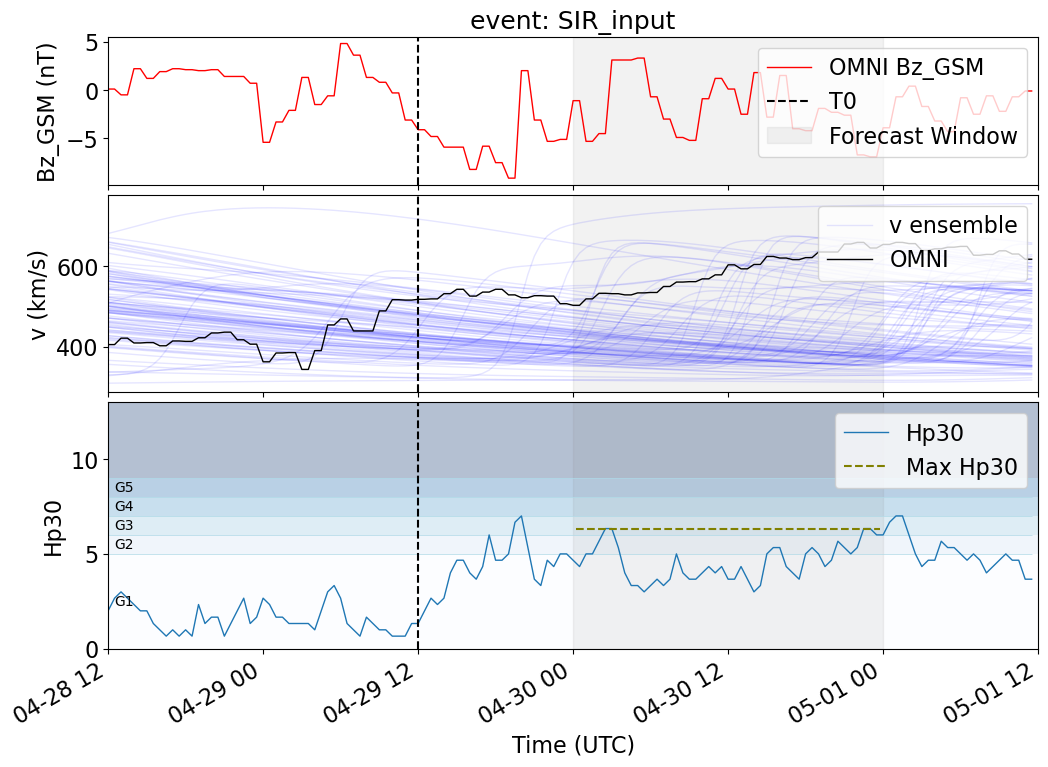

In [34]:
## Check no discontinuities are present
from storm_regression.plotting import plot_window_data

print('Check no discontinuities in these windows')
for i in [2500]:
    plot_window_data(dataset, i)

In [15]:
## Inspect a single processed df
import pandas as pd

paths = get_project_paths()
filepath = paths['huxt_data_shared'] / 'HUXt3_modified' / 'HUXt_rotation_1892.parquet'
single_df = pd.read_parquet(filepath)
single_df

,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,v_9,...,B_GSM,theta_c,theta_boyle,Boyle,Newell,Viscous,hp30,ICME_flag,MC_flag,SIR_flag
1995-01-28 12:00:00,317.510612,327.681513,339.588936,753.941288,308.433937,383.169139,708.072873,321.803146,325.343476,308.998128,...,3.494281,0.991722,0.991722,12.151552,556.062660,201.824845,0.667,0,0,0
1995-01-28 12:30:00,318.296662,329.248139,339.906986,753.463726,308.457945,382.103218,706.326838,321.341981,324.875724,309.043170,...,3.494281,0.991722,0.991722,12.151552,556.062660,201.824845,0.667,0,0,0
1995-01-28 13:00:00,319.132456,330.959879,340.176180,752.941788,308.485491,381.037306,704.514169,320.893208,324.418538,309.088638,...,2.549510,0.817645,0.817645,10.080101,278.114093,100.856413,0.333,0,0,0
1995-01-28 13:30:00,320.017326,332.823445,340.397459,752.373064,308.517146,379.972514,702.634032,320.456966,323.971912,309.134402,...,2.549510,0.817645,0.817645,10.080101,278.114093,100.856413,0.333,0,0,0
1995-01-28 14:00:00,320.949926,334.844735,340.572081,751.755327,308.553501,378.909839,700.686019,320.033402,323.535840,309.180336,...,2.808914,1.390943,1.390943,15.176667,992.380746,264.393789,0.000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995-02-23 15:00:00,306.728432,318.113486,340.679585,755.774825,309.985806,329.199913,753.183777,428.116281,432.496419,313.405839,...,4.333590,2.410686,2.410686,46.673065,4310.068637,1049.807171,1.333,0,0,0
1995-02-23 15:30:00,306.679254,318.017317,340.239493,755.572550,310.008238,328.874059,752.838085,426.397496,430.817320,313.341771,...,4.333590,2.410686,2.410686,46.673065,4310.068637,1049.807171,1.000,0,0,0
1995-02-23 16:00:00,306.635891,317.923872,339.806739,755.368560,310.031999,328.539516,752.487226,424.695827,429.149743,313.266698,...,3.567913,2.912361,2.912361,45.010127,4383.411182,945.530868,1.000,0,0,0
1995-02-23 16:30:00,306.598544,317.833905,339.380753,755.162752,310.056792,328.197222,752.130584,423.011131,427.493906,313.181161,...,3.567913,2.912361,2.912361,45.010127,4383.411182,945.530868,0.667,0,0,0


  SIR flagged: 35380 timesteps (13.4%)
Found 1282 SIR start events


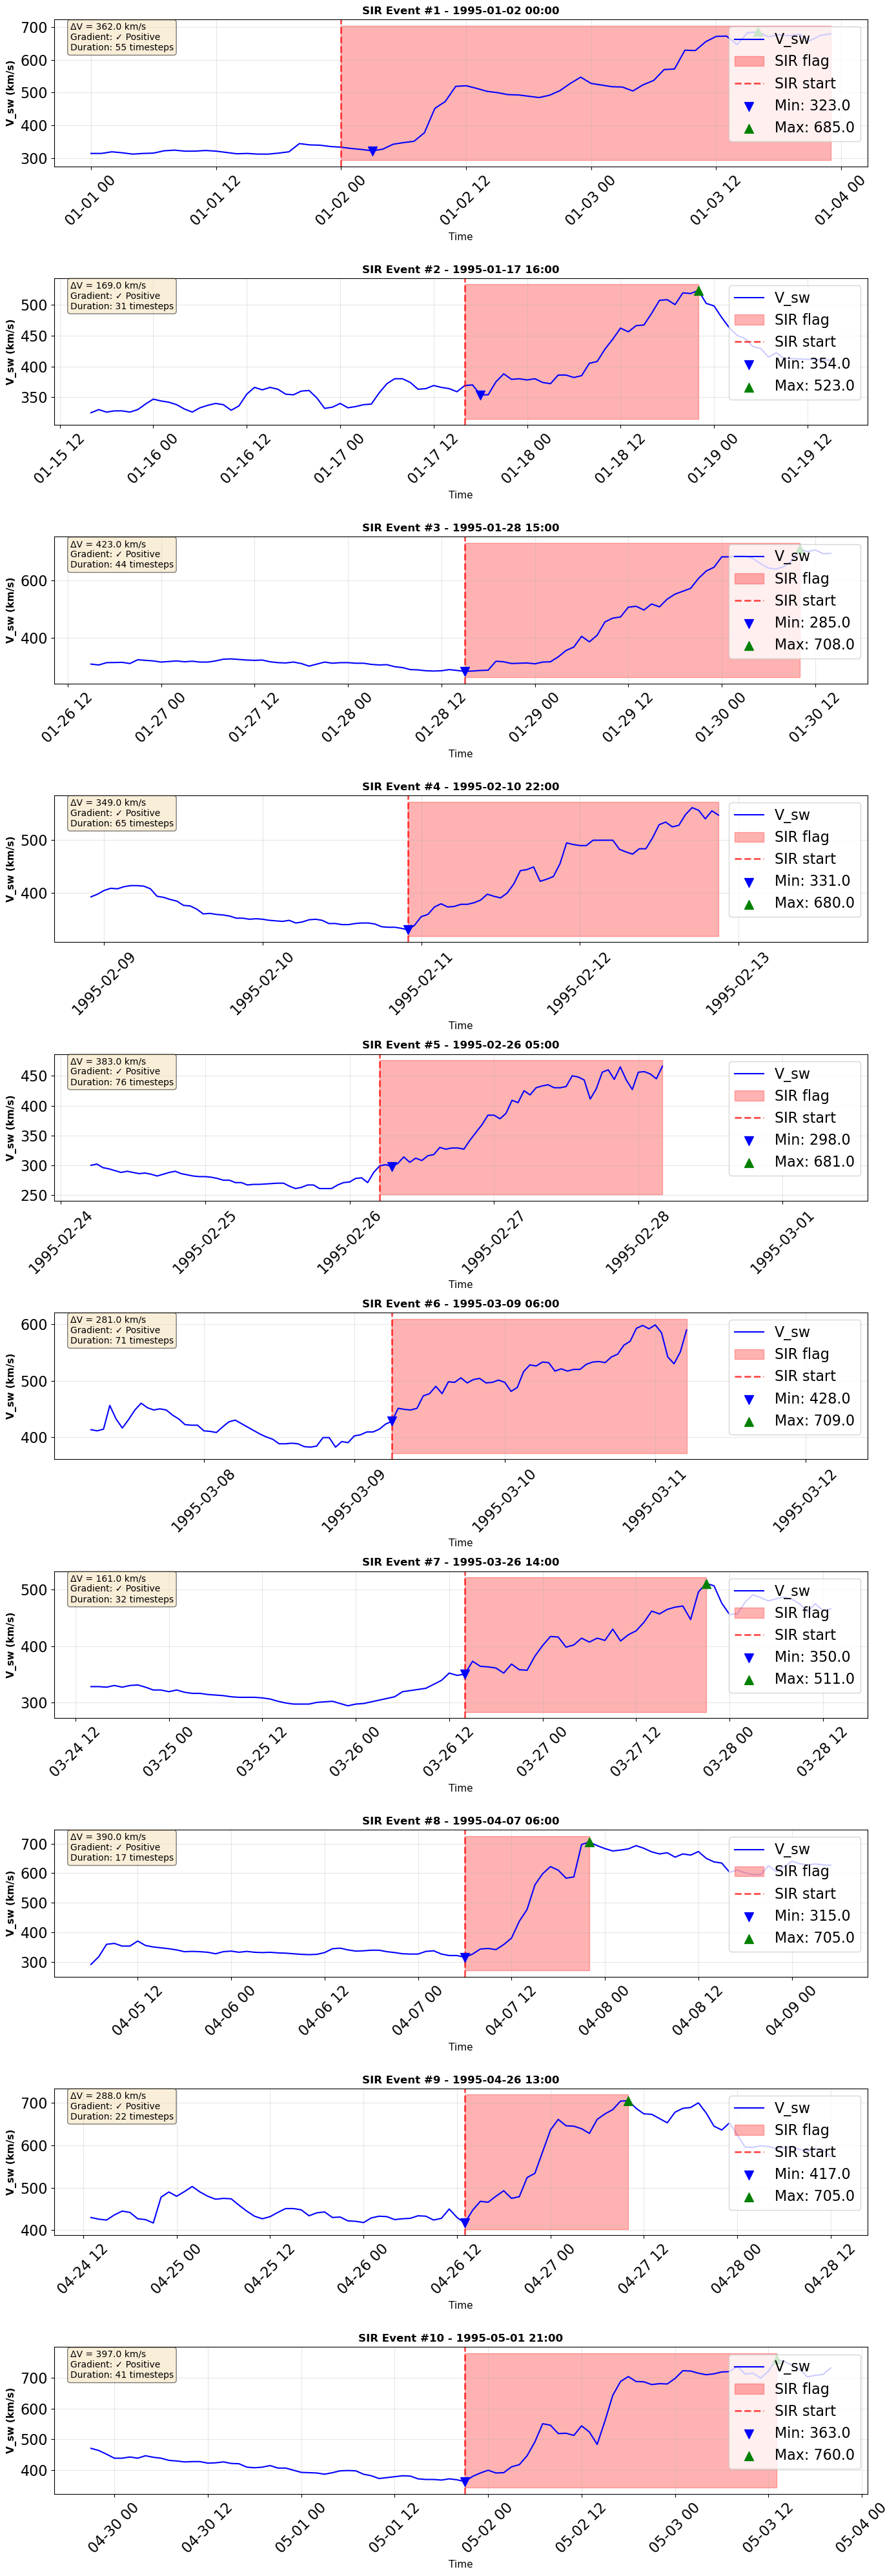


SIR DETECTION SUMMARY
Total SIR events: 1282
  Positive gradient: 1159 (90.4%)
  Negative gradient: 123 (9.6%)



In [44]:
from scipy.ndimage import maximum_filter1d, minimum_filter1d
from numpy.lib.stride_tricks import sliding_window_view
from storm_utils.data_processing import load_full_omni
import numpy as np

df = load_full_omni()

# ===== SIR Flag =====
verbose = True
v_sw = df['V_sw'].values

# Check for issues
v_sw = np.nan_to_num(v_sw, nan=0.0)

# Calculate window size
sir_time_window_hours = 24
sir_velocity_threshold = 150
time_delta_hours = (df.index[1] - df.index[0]).total_seconds() / 3600
n_points = int(sir_time_window_hours / time_delta_hours)
window_size = min(n_points * 2 + 1, len(v_sw))

# Initialize SIR flag
sir_flag = np.zeros(len(v_sw), dtype=int)

# For each timestep, check the window around it
half_window = window_size // 2

for i in range(half_window, len(v_sw) - half_window):
    # Extract window
    window_start = i - half_window
    window_end = i + half_window + 1
    v_window = v_sw[window_start:window_end]
    
    # Find min and max positions in window
    idx_max_in_window = np.argmax(v_window)
    idx_min_in_window = np.argmin(v_window)
    
    # Convert to absolute indices
    idx_max_abs = window_start + idx_max_in_window
    idx_min_abs = window_start + idx_min_in_window
    
    # Condition 1: Velocity range > threshold
    v_max = v_window[idx_max_in_window]
    v_min = v_window[idx_min_in_window]
    v_range = v_max - v_min
    
    # Condition 2: Max occurs AFTER min (positive gradient)
    # Condition 3: Current timestep is between min and max (inclusive)
    if v_range > sir_velocity_threshold and idx_max_abs > idx_min_abs:
        if idx_min_abs <= i <= idx_max_abs:
            sir_flag[i] = 1

df["SIR_flag"] = sir_flag

if verbose:
    print(f"  SIR flagged: {df['SIR_flag'].sum()} timesteps ({df['SIR_flag'].sum()/len(df)*100:.1f}%)")

import matplotlib.pyplot as plt
import numpy as np

def plot_sir_regions(df, n_regions=5, window_hours=48):
    """
    Plot regions where SIR flags are present to verify detection logic.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with SIR_flag and V_sw columns
    n_regions : int
        Number of SIR regions to plot
    window_hours : int
        Hours to show around each SIR (for context)
    """
    # Find SIR transitions (where flag goes from 0 to 1)
    sir_flag = df['SIR_flag'].values
    sir_starts = []
    
    for i in range(1, len(sir_flag)):
        if sir_flag[i] == 1 and sir_flag[i-1] == 0:
            sir_starts.append(i)
    
    print(f"Found {len(sir_starts)} SIR start events")
    
    if len(sir_starts) == 0:
        print("No SIR events found!")
        return
    
    # Plot first n_regions
    n_to_plot = min(n_regions, len(sir_starts))
    
    # Calculate window size
    time_delta_hours = (df.index[1] - df.index[0]).total_seconds() / 3600
    n_points_context = int(window_hours / time_delta_hours)
    
    fig, axes = plt.subplots(n_to_plot, 1, figsize=(14, 4*n_to_plot))
    if n_to_plot == 1:
        axes = [axes]
    
    for plot_idx, sir_start in enumerate(sir_starts[:n_to_plot]):
        ax = axes[plot_idx]
        
        # Define window around SIR
        window_start = max(0, sir_start - n_points_context)
        window_end = min(len(df), sir_start + n_points_context)
        
        # Extract data
        times = df.index[window_start:window_end]
        v_window = df['V_sw'].values[window_start:window_end]
        sir_flags = df['SIR_flag'].values[window_start:window_end]
        
        # Plot velocity
        ax.plot(times, v_window, 'b-', linewidth=1.5, label='V_sw')
        
        # Plot SIR flag as shaded regions
        sir_mask = sir_flags.astype(bool)
        ax.fill_between(times, ax.get_ylim()[0], ax.get_ylim()[1], where=sir_mask, 
                        alpha=0.3, color='red', label='SIR flag')
        
        # Mark the detection point
        ax.axvline(df.index[sir_start], color='red', linestyle='--', 
                  linewidth=2, label='SIR start', alpha=0.7)
        
        # Find full SIR period
        sir_region_start = sir_start
        sir_region_end = sir_start
        
        # Extend to find full SIR period
        while sir_region_end < len(sir_flag) and sir_flag[sir_region_end] == 1:
            sir_region_end += 1
        
        # Get velocity in SIR region
        v_sir = df['V_sw'].values[sir_region_start:sir_region_end]
        
        if len(v_sir) > 0:
            v_min_val = np.min(v_sir)
            v_max_val = np.max(v_sir)
            v_min_idx = sir_region_start + np.argmin(v_sir)
            v_max_idx = sir_region_start + np.argmax(v_sir)
            
            # Mark min and max
            ax.scatter([df.index[v_min_idx]], [v_min_val], 
                      color='blue', s=100, marker='v', label=f'Min: {v_min_val:.1f}', zorder=5)
            ax.scatter([df.index[v_max_idx]], [v_max_val], 
                      color='green', s=100, marker='^', label=f'Max: {v_max_val:.1f}', zorder=5)
            
            # Annotate with range and gradient direction
            v_range = v_max_val - v_min_val
            gradient_ok = v_max_idx > v_min_idx
            
            ax.text(0.02, 0.98, 
                   f'ΔV = {v_range:.1f} km/s\n'
                   f'Gradient: {"✓ Positive" if gradient_ok else "✗ Negative"}\n'
                   f'Duration: {sir_region_end - sir_region_start} timesteps',
                   transform=ax.transAxes, fontsize=10, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_ylabel('V_sw (km/s)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Time', fontsize=11)
        ax.set_title(f'SIR Event #{plot_idx + 1} - {df.index[sir_start].strftime("%Y-%m-%d %H:%M")}', 
                    fontsize=12, fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(alpha=0.3)
        
        # Format x-axis
        ax.tick_params(axis='x', rotation=45)
        
        # Set y-limits to show all data without cutoff
        y_min = np.min(v_window)
        y_max = np.max(v_window)
        y_range = y_max - y_min
        ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\n{'='*80}")
    print(f"SIR DETECTION SUMMARY")
    print(f"{'='*80}")
    
    # Check all SIR regions for gradient
    n_positive_gradient = 0
    n_negative_gradient = 0
    
    for sir_start in sir_starts:
        sir_region_end = sir_start
        while sir_region_end < len(sir_flag) and sir_flag[sir_region_end] == 1:
            sir_region_end += 1
        
        v_sir = df['V_sw'].values[sir_start:sir_region_end]
        if len(v_sir) > 0:
            if np.argmax(v_sir) > np.argmin(v_sir):
                n_positive_gradient += 1
            else:
                n_negative_gradient += 1
    
    print(f"Total SIR events: {len(sir_starts)}")
    print(f"  Positive gradient: {n_positive_gradient} ({n_positive_gradient/len(sir_starts)*100:.1f}%)")
    print(f"  Negative gradient: {n_negative_gradient} ({n_negative_gradient/len(sir_starts)*100:.1f}%)")
    print(f"{'='*80}\n")


# Usage:
plot_sir_regions(df, n_regions=10, window_hours=48)